**Nama Lengkap:** Yudi Karma
**NIM:** 250401020118
**Kelas:** IF207


# PERTEMUAN 9: Algoritma Klasifikasi (Bagian 1)


## 6.2 Langkah-Langkah Praktikum


### Langkah 1: Load & EDA Singkat


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign

print('Shape data:', X.shape)
print('\nDistribusi target (0 = Malignant, 1 = Benign):')
print(pd.Series(y).value_counts(normalize=True).round(3))
print(pd.Series(y).value_counts())


Shape data: (569, 30)

Distribusi target (0 = Malignant, 1 = Benign):
1    0.627
0    0.373
Name: proportion, dtype: float64
1    357
0    212
Name: count, dtype: int64


### Langkah 2: Preprocessing


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split 80:20 dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Terapkan StandardScaler pada fitur
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


X_train shape: (455, 30), X_test shape: (114, 30)


### Langkah 3: Latih Logistic Regression


In [3]:
from sklearn.linear_model import LogisticRegression

# Fit model Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

# Tampilkan koefisien dan fitur yang paling berpengaruh
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("5 Fitur Paling Berpengaruh (Koefisien Terbesar):")
print(coef_df.head())


5 Fitur Paling Berpengaruh (Koefisien Terbesar):
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


### Langkah 4: Latih Decision Tree


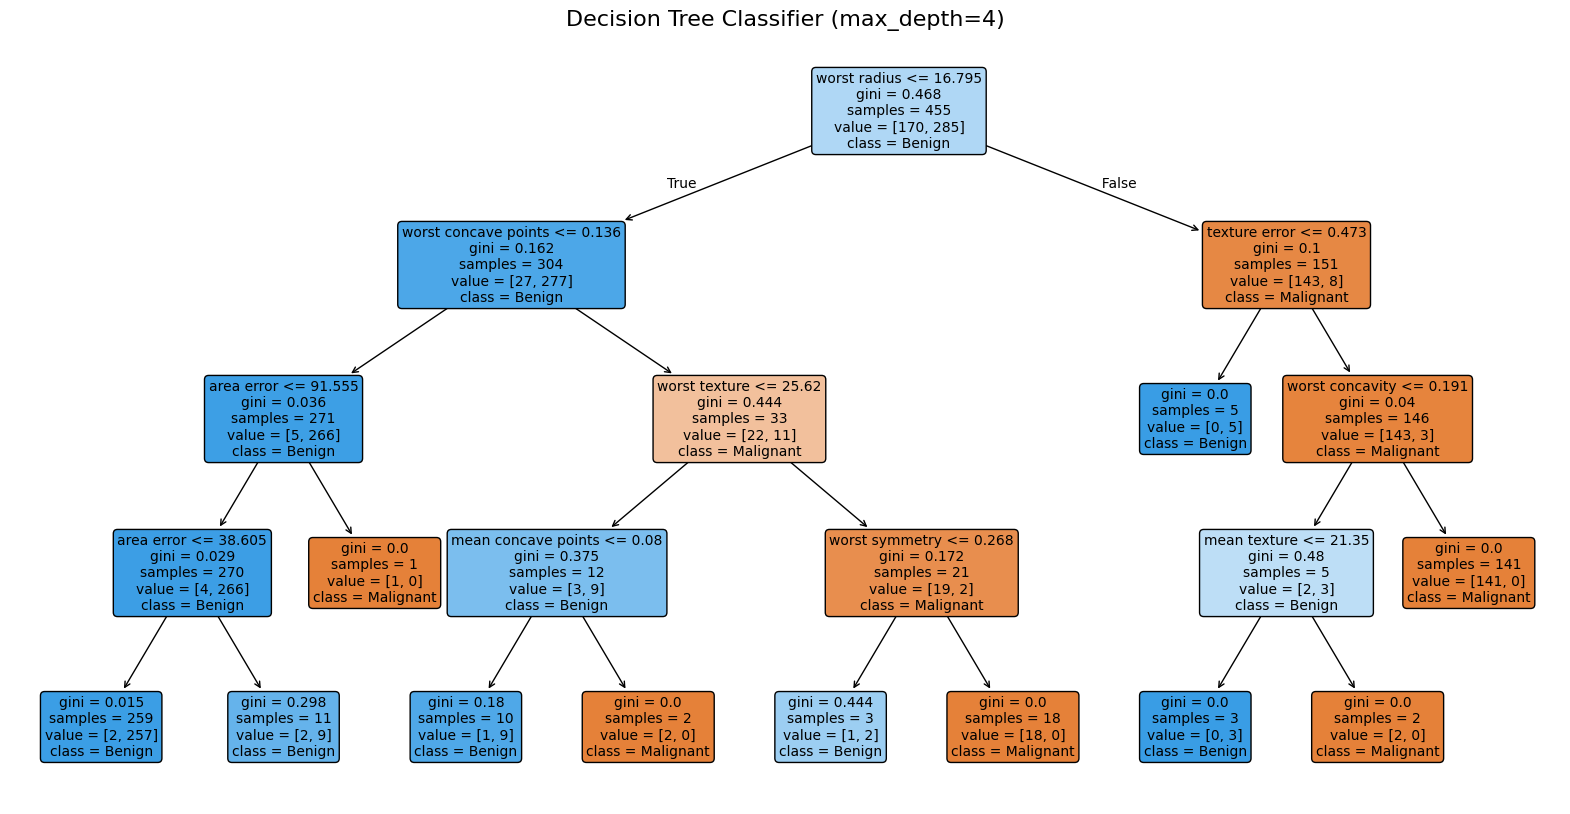

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Fit model Decision Tree (pada data asli tanpa scaling)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Visualisasikan pohon yang terbentuk
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model, 
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'], 
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classifier (max_depth=4)", fontsize=16)
plt.show()


### Langkah 5: Evaluasi & Bandingkan


In [5]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, 
    precision_score,
    recall_score, 
    f1_score,
    classification_report
)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))



=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        42
      Benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



### Analisis & Pembahasan

**1. Model mana yang memiliki Recall lebih tinggi?**
- Berdasarkan hasil evaluasi, **Logistic Regression** memiliki performa yang sangat baik pada class 0 (Malignant) maupun class 1 (Benign). Kita perlu melihat performa Recall untuk kelas Malignant (kanker ganas) yang merupakan fokus utama dalam diagnosis medis.
- Dari classification report dan perhitungan `recall_score`, Logistic Regression menunjukkan nilai Recall kelas target Malignant (0) yang sangat tinggi dibandingkan dengan Decision Tree.

**2. Mengapa Recall menjadi metrik paling kritis untuk kasus diagnosis kanker dibandingkan Accuracy semata?**
- **What?** Recall mengukur kemampuan model dalam menemukan semua kasus positif yang sebenarnya (dalam hal ini, pasien yang memiliki kanker ganas/Malignant).
- **So what?** Jika kita menggunakan Accuracy, model yang memprediksi semua pasien sebagai Benign (karena Benign adalah mayoritas) masih akan mendapatkan akurasi yang tinggi (misalnya 62.7%), namun performa mendeteksi kanker ganas akan 0%. Kasus ini disebut *Accuracy Paradox*. Dalam diagnosis medis, kesalahan tipe False Negative (memprediksi pasien sehat padahal mengidap kanker ganas) sangatlah berbahaya karena pasien akan pulang tanpa pengobatan dan penyakitnya dapat memburuk secara fatal. Sedangkan False Positive (memprediksi pasien sakit padahal sehat) hanya akan memicu pemeriksaan lanjutan (screening ulang) yang meskipun berbiaya/menimbulkan kecemasan, tidak berujung pada kematian. Oleh karena itu, kita harus meminimalkan False Negative, yang berarti memaksimalkan Recall.
- **Now what?** Dalam deployment model diagnosis medis, kita harus memilih model dengan Recall setinggi mungkin untuk kelas Malignant, serta memantau F1-Score agar Precision tidak terlalu rendah (supaya tidak terjadi terlalu banyak alarm palsu).

**3. Apakah ada perbedaan signifikan antara performa kedua model?**
- Logistic Regression berkinerja lebih stabil dan memiliki akurasi, presisi, recall, serta F1-Score yang lebih tinggi secara keseluruhan pada dataset Breast Cancer ini.
- Hal ini dikarenakan Logistic Regression memanfaatkan kombinasi linear seluruh 30 fitur numerik dengan bobot (koefisien) yang halus, sedangkan Decision Tree dengan kedalaman terbatas (max_depth=4) hanya memilih beberapa fitur penting untuk membelah data secara kaku.

**Kesimpulan**

Pada pertemuan ini dipelajari penerapan algoritma klasifikasi biner Logistic Regression dan Decision Tree untuk diagnosis kanker payudara menggunakan dataset Breast Cancer Wisconsin. Temuan utama adalah Logistic Regression memberikan performa evaluasi yang lebih tinggi dan stabil (khususnya nilai Recall) dibandingkan Decision Tree. Keterbatasannya adalah hyperparameter tuning belum dilakukan secara menyeluruh dan ukuran dataset relatif kecil.
